[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed



--- Backtest Performance Summary (Past 1 Year) ---
Total Spread Return (Ratio Units): -3.0436
Maximum Drawdown (Ratio Units): 37.6010
Total Trade Executions/Adjustments: 29


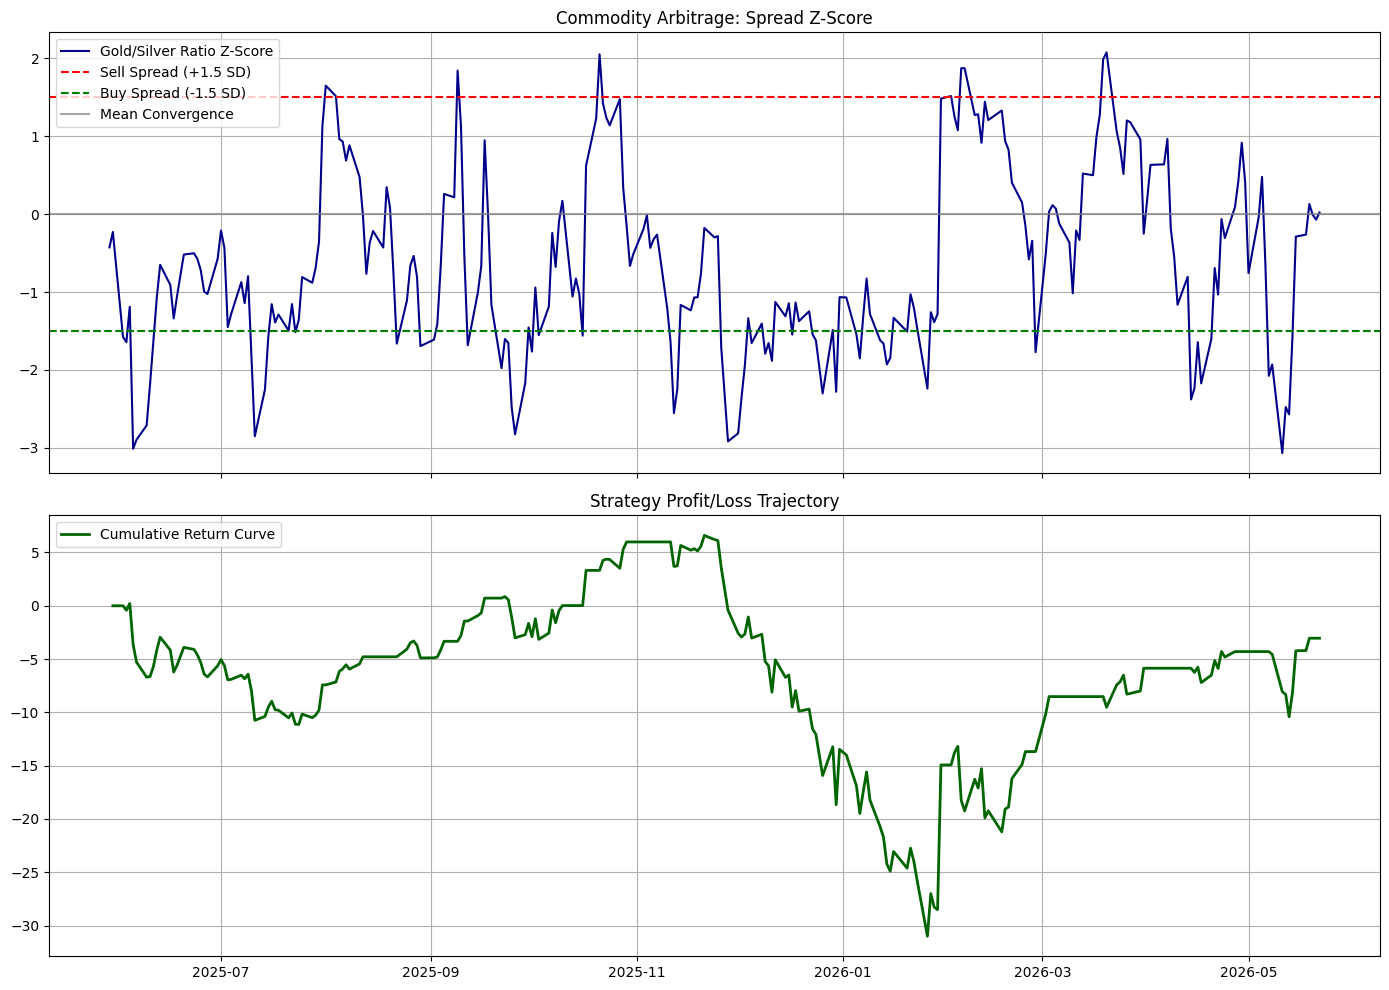

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Fetch historical data for two highly liquid, correlated commodities
print("Downloading historical commodity futures data...")
asset_a = yf.download("GC=F", start="2025-05-01", end="2026-05-24")
asset_b = yf.download("SI=F", start="2025-05-01", end="2026-05-24")

# Extract only the Close columns safely
close_a = asset_a['Close'].squeeze()
close_b = asset_b['Close'].squeeze()

# 2. Safely align into a unified DataFrame
df = pd.DataFrame({
    'Gold': close_a,
    'Silver': close_b
}).dropna()

if df.empty:
    raise ValueError("Data download failed or data frames could not align. Check connection.")

# 3. Compute the Ratio Spread (Gold Price / Silver Price)
df['Spread'] = df['Gold'] / df['Silver']

# Rolling metrics for Mean Reversion
window = 20
df['Spread_Mean'] = df['Spread'].rolling(window=window).mean()
df['Spread_Std'] = df['Spread'].rolling(window=window).std()
df['Z_Score'] = (df['Spread'] - df['Spread_Mean']) / df['Spread_Std']
df.dropna(inplace=True)

# 4. Initialize Backtesting Variables
df['Position'] = 0
current_pos = 0  # 1 = Long Spread, -1 = Short Spread, 0 = Flat

ENTRY_HIGH = 1.5
ENTRY_LOW = -1.5
EXIT_MEAN = 0.0

# 5. Iterative Simulation Loop
position_history = []
for idx, row in df.iterrows():
    z = row['Z_Score']
    
    if current_pos == 0:
        if z >= ENTRY_HIGH:
            current_pos = -1  # Short the spread (Sell Gold, Buy Silver)
        elif z <= ENTRY_LOW:
            current_pos = 1   # Long the spread (Buy Gold, Sell Silver)
    elif current_pos == 1:
        if z >= EXIT_MEAN:
            current_pos = 0   # Exit
    elif current_pos == -1:
        if z <= EXIT_MEAN:
            current_pos = 0   # Exit
            
    position_history.append(current_pos)

df['Position'] = position_history

# 6. Performance Metrics 
df['Spread_Change'] = df['Spread'].diff()
# Shift position by 1 day to prevent look-ahead bias
df['Daily_Return'] = df['Position'].shift(1) * df['Spread_Change']
df['Cumulative_Return'] = df['Daily_Return'].cumsum()

# 7. Summary and Reporting
print("\n--- Backtest Performance Summary (Past 1 Year) ---")
total_return_units = df['Daily_Return'].sum()
total_trades = len(df[df['Position'].diff() != 0])
max_dd = (df['Cumulative_Return'].cummax() - df['Cumulative_Return']).max()

print(f"Total Spread Return (Ratio Units): {total_return_units:.4f}")
print(f"Maximum Drawdown (Ratio Units): {max_dd:.4f}")
print(f"Total Trade Executions/Adjustments: {total_trades}")

# 8. Visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Z-Score Chart
ax1.plot(df.index, df['Z_Score'], label='Gold/Silver Ratio Z-Score', color='darkblue')
ax1.axhline(ENTRY_HIGH, color='red', linestyle='--', label='Sell Spread (+1.5 SD)')
ax1.axhline(ENTRY_LOW, color='green', linestyle='--', label='Buy Spread (-1.5 SD)')
ax1.axhline(EXIT_MEAN, color='gray', linestyle='-', alpha=0.7, label='Mean Convergence')
ax1.set_title("Commodity Arbitrage: Spread Z-Score")
ax1.legend(loc='upper left')
ax1.grid(True)

# Return Chart
ax2.plot(df.index, df['Cumulative_Return'], label='Cumulative Return Curve', color='darkgreen', linewidth=2)
ax2.set_title("Strategy Profit/Loss Trajectory")
ax2.legend(loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

 ♟ COMMODITY FUTURES STATISTICAL ARBITRAGE ENGINE — BACKTEST


12:34:22 [INFO] Synchronizing 1-year historical data vectors for: Precious Metals: Gold vs Silver
12:34:22 [INFO] Synchronizing 1-year historical data vectors for: Energy Complex: Crude Oil vs Heating Oil
12:34:23 [INFO] Synchronizing 1-year historical data vectors for: Agriculture Grains: Corn vs Soybeans
12:34:24 [INFO] Synchronizing 1-year historical data vectors for: Industrial Base Metals: Copper vs Aluminum



═════════════════════════════════════════════════════════════════
 FINAL SYSTEM PERFORMANCE PORTFOLIO LEDGER
═════════════════════════════════════════════════════════════════
                           Universe Matrix  Net Profit/Loss ($)  Peak Drawdown ($)  Closed Trades  Win Rate (%)
           Precious Metals: Gold vs Silver             78639.42           35202.83              9         66.67
  Energy Complex: Crude Oil vs Heating Oil            -20012.08           31728.99              4          0.00
      Agriculture Grains: Corn vs Soybeans               327.33            2653.06              5         80.00
Industrial Base Metals: Copper vs Aluminum            -23144.22           26671.80              3          0.00

═════════════════════════════════════════════════════════════════
💾 Audit matrices exported to target document table → commodity_arb_results.xlsx
═════════════════════════════════════════════════════════════════


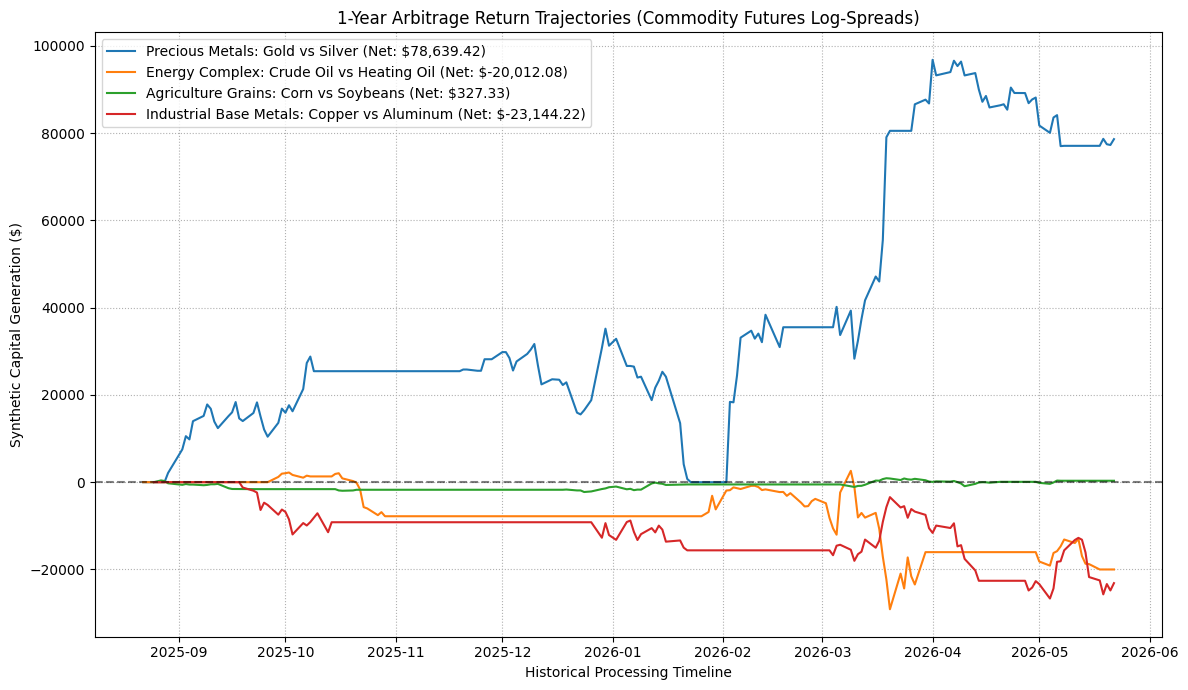

In [3]:
import os
import time
import subprocess
import logging
from datetime import datetime
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Install required formatting and analytics packages silently
subprocess.run([
    "pip", "install", "pandas", "numpy", "openpyxl", "yfinance", "matplotlib", "-q"
], check=False)

# ═══════════════════════════════════════════════════════════
#  SETTINGS
# ═══════════════════════════════════════════════════════════
PAPER_CAPITAL        = 100_000     # Allocation base for contract margining
ALLOCATION_PER_PAIR  = 0.25        # Max risk capacity per spread pair
LOOKBACK             = 40          # Statistical window for rolling OLS and tracking bands

ENTRY_ZSCORE         = 2.0         # Absolute Z-score threshold to trigger mean-reversion trade
EXIT_ZSCORE          = 0.5         # Target convergence threshold to close out positions
STOP_ZSCORE          = 3.5         # Risk exit if structural cointegration breaks down

EXCEL_FILE           = "commodity_arb_results.xlsx"

# Highly correlated global commodity asset configurations
# Structure: (Asset A Ticker, Asset B Ticker, Name, Multiplier A, Multiplier B)
COMMODITY_UNIVERSES = [
    ("GC=F", "SI=F", "Precious Metals: Gold vs Silver", 100, 5000),
    ("CL=F", "HO=F", "Energy Complex: Crude Oil vs Heating Oil", 1000, 42000),
    ("ZC=F", "ZS=F", "Agriculture Grains: Corn vs Soybeans", 50, 50),
    ("HG=F", "ALI=F", "Industrial Base Metals: Copper vs Aluminum", 25000, 25)
]

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("CommodityArb")

# ═══════════════════════════════════════════════════════════
#  SPREAD MATHEMATICS & CORE ENGINES
# ═══════════════════════════════════════════════════════════
def compute_rolling_hedge_ratio(log_a, log_b, window):
    """
    Computes a dynamically shifting rolling hedge ratio (Beta) via OLS.
    Employs an expanding/rolling window calculation safely.
    """
    hedge_ratios = np.zeros(len(log_a))
    for i in range(len(log_a)):
        if i < window:
            hedge_ratios[i] = np.nan
            continue
        y = log_a[(i - window + 1):i + 1]
        x = log_b[(i - window + 1):i + 1]
        X = np.column_stack([x, np.ones(len(x))])
        beta, _ = np.linalg.lstsq(X, y, rcond=None)[0]
        hedge_ratios[i] = beta
    return pd.Series(hedge_ratios, index=log_a.index)

def backtest_pair(ticker_a, ticker_b, name, mult_a, mult_b):
    log.info(f"Synchronizing 1-year historical data vectors for: {name}")
    
    # Secure past 1 year of daily historical data pools
    data_a = yf.download(ticker_a, start="2025-05-01", end="2026-05-24", progress=False)
    data_b = yf.download(ticker_b, start="2025-05-01", end="2026-05-24", progress=False)
    
    # Guard clause: Flatten multi-index columns if generated by yfinance
    if isinstance(data_a.columns, pd.MultiIndex):
        close_a = data_a.xs('Close', axis=1, level=0).squeeze()
        close_b = data_b.xs('Close', axis=1, level=0).squeeze()
    else:
        close_a = data_a['Close']
        close_b = data_b['Close']

    df = pd.DataFrame({'Price_A': close_a, 'Price_B': close_b}).dropna()
    
    if df.empty:
        log.warning(f"Failed to compile data intersection for {name}. Skipping.")
        return None

    # Calculate log price series to determine scale-invariant relationship
    df['Log_A'] = np.log(df['Price_A'])
    df['Log_B'] = np.log(df['Price_B'])
    
    # Calculate rolling statistical foundations
    df['Hedge_Ratio'] = compute_rolling_hedge_ratio(df['Log_A'], df['Log_B'], LOOKBACK)
    df['Spread'] = df['Log_A'] - (df['Hedge_Ratio'] * df['Log_B'])
    df['Spread_Mean'] = df['Spread'].rolling(window=LOOKBACK).mean()
    df['Spread_Std'] = df['Spread'].rolling(window=LOOKBACK).std()
    df['Z_Score'] = (df['Spread'] - df['Spread_Mean']) / df['Spread_Std']
    df.dropna(inplace=True)

    # ═══════════════════════════════════════════════════════════
    #  STATE MACHINE SIMULATION
    # ═══════════════════════════════════════════════════════════
    position = 0  # 0 = Flat, 1 = Long Spread (Long A, Short B), -1 = Short Spread (Short A, Long B)
    positions = []
    exit_reasons = []
    
    entry_a, entry_b = 0.0, 0.0
    current_trade_pnl = 0.0
    trade_logs = []

    for idx, row in df.iterrows():
        z = row['Z_Score']
        p_a = row['Price_A']
        p_b = row['Price_B']
        hr = row['Hedge_Ratio']
        
        # State: Flat -> Evaluation of Entries
        if position == 0:
            if z >= ENTRY_ZSCORE:
                position = -1  # Short Spread
                entry_a, entry_b = p_a, p_b
                exit_reasons.append("ENTRY_SHORT")
            elif z <= -ENTRY_ZSCORE:
                position = 1   # Long Spread
                entry_a, entry_b = p_a, p_b
                exit_reasons.append("ENTRY_LONG")
            else:
                exit_reasons.append("FLAT")
        
        # State: Holding Positions -> Evaluation of Exit Thresholds
        elif position == 1:  # Long Spread (Long A, Short B)
            pnl_a = (p_a - entry_a) * mult_a
            pnl_b = (entry_b - p_b) * mult_b * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z >= -EXIT_ZSCORE:
                position = 0
                exit_reasons.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
            elif z <= -STOP_ZSCORE:
                position = 0
                exit_reasons.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
            else:
                exit_reasons.append("HOLD_LONG")
                
        elif position == -1:  # Short Spread (Short A, Long B)
            pnl_a = (entry_a - p_a) * mult_a
            pnl_b = (p_b - entry_b) * mult_b * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z <= EXIT_ZSCORE:
                position = 0
                exit_reasons.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
            elif z >= STOP_ZSCORE:
                position = 0
                exit_reasons.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
            else:
                exit_reasons.append("HOLD_SHORT")

        positions.append(position)

    df['Position_State'] = positions
    df['Tracking_Status'] = exit_reasons
    
    # Calculate daily execution delta values
    df['Delta_Price_A'] = df['Price_A'].diff()
    df['Delta_Price_B'] = df['Price_B'].diff()
    
    # Realized asset PnL contributions based on yesterday's signals to prevent lookahead bias
    df['PnL_A'] = df['Position_State'].shift(1) * df['Delta_Price_A'] * mult_a
    df['PnL_B'] = -df['Position_State'].shift(1) * df['Delta_Price_B'] * mult_b * df['Hedge_Ratio']
    df['Daily_Combined_PnL'] = (df['PnL_A'] + df['PnL_B']).fillna(0)
    df['Cumulative_PnL'] = df['Daily_Combined_PnL'].cumsum()
    
    return df, trade_logs

# ═══════════════════════════════════════════════════════════
#  MAIN PROCESSING EXECUTION LAYER
# ═══════════════════════════════════════════════════════════
def run_macro_backtest():
    os.system("cls" if os.name == "nt" else "clear")
    print("="*65)
    print(" ♟ COMMODITY FUTURES STATISTICAL ARBITRAGE ENGINE — BACKTEST")
    print("="*65)
    
    all_summary_stats = []
    compiled_trades = []
    
    fig, ax = plt.subplots(figsize=(12, 7))

    with pd.ExcelWriter(EXCEL_FILE, engine="openpyxl") as writer:
        for ticker_a, ticker_b, name, mult_a, mult_b in COMMODITY_UNIVERSES:
            result = backtest_pair(ticker_a, ticker_b, name, mult_a, mult_b)
            if result is None:
                continue
                
            pair_df, trades = result
            compiled_trades.extend(trades)
            
            # Export clean processing matrix tabs directly to Excel
            clean_sheet_name = name.split(":")[0].replace(" ", "_")
            pair_df[['Price_A', 'Price_B', 'Z_Score', 'Hedge_Ratio', 'Cumulative_PnL']].to_excel(writer, sheet_name=clean_sheet_name)
            
            # Extract historical structural tracking metrics
            total_pair_pnl = pair_df['Daily_Combined_PnL'].sum()
            max_drawdown = (pair_df['Cumulative_PnL'].cummax() - pair_df['Cumulative_PnL']).max()
            
            pair_trades_df = pd.DataFrame(trades)
            if not pair_trades_df.empty:
                win_rate = (len(pair_trades_df[pair_trades_df['PnL'] > 0]) / len(pair_trades_df)) * 100
            else:
                win_rate = 0.0

            all_summary_stats.append({
                "Universe Matrix": name,
                "Net Profit/Loss ($)": round(total_pair_pnl, 2),
                "Peak Drawdown ($)": round(max_drawdown, 2),
                "Closed Trades": len(trades),
                "Win Rate (%)": round(win_rate, 2)
            })
            
            # Append trajectory tracking to the data visualization plot
            ax.plot(pair_df.index, pair_df['Cumulative_PnL'], label=f"{name} (Net: ${total_pair_pnl:,.2f})")

        # Save macro analytical tracking summaries to Excel sheets
        summary_df = pd.DataFrame(all_summary_stats)
        summary_df.to_excel(writer, sheet_name="Performance Summary", index=False)
        if compiled_trades:
            pd.DataFrame(compiled_trades).to_excel(writer, sheet_name="Master Trade Ledger", index=False)

    # Finalize visual performance canvas plots
    ax.set_title("1-Year Arbitrage Return Trajectories (Commodity Futures Log-Spreads)")
    ax.set_xlabel("Historical Processing Timeline")
    ax.set_ylabel("Synthetic Capital Generation ($)")
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":")
    
    print("\n" + "═"*65)
    print(" FINAL SYSTEM PERFORMANCE PORTFOLIO LEDGER")
    print("═"*65)
    print(summary_df.to_string(index=False))
    print("\n" + "═"*65)
    print(f"💾 Audit matrices exported to target document table → {EXCEL_FILE}")
    print("═"*65)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_macro_backtest()

12:49:27 [INFO] System Initialized. Preparing historical spreadsheet generation pipelines...
12:49:27 [INFO] Synchronizing historical data vectors for: Precious Metals: Gold vs Silver
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - Signal: Short Spread entered at Z-Score: 1.62
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - TakeProfit: Spread reverted. Trade PnL: $1,966.09
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - Signal: Long Spread entered at Z-Score: -2.44
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - TakeProfit: Spread reverted. Trade PnL: $-5,638.97
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - Signal: Short Spread entered at Z-Score: 1.69
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - TakeProfit: Spread reverted. Trade PnL: $-3,286.23
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - Signal: Long Spread entered at Z-Score: -1.72
12:49:29 [INFO] [Precious Metals: Gold vs Silver] - TakeProfit: Spread reverted. Trade PnL: $894.80
12:49:29 [INFO] 


═════════════════════════════════════════════════════════════════
 SYSTEM PERFORMANCE AUDIT LEDGER COMPLETE
═════════════════════════════════════════════════════════════════
                           Universe Matrix  Net Profit/Loss ($)  Peak Drawdown ($)  Closed Trades  Win Rate (%)
           Precious Metals: Gold vs Silver             96428.93           48668.26             70         55.71
  Energy Complex: Crude Oil vs Heating Oil             37764.68           33195.98             65         50.77
      Agriculture Grains: Corn vs Soybeans             12957.70           28301.91             69         49.28
Industrial Base Metals: Copper vs Aluminum           -109249.95          122212.90             70         35.71

═════════════════════════════════════════════════════════════════
💾 Audit metrics, logs, and parameters written to unified file -> commodity_arb_results.xlsx
═════════════════════════════════════════════════════════════════


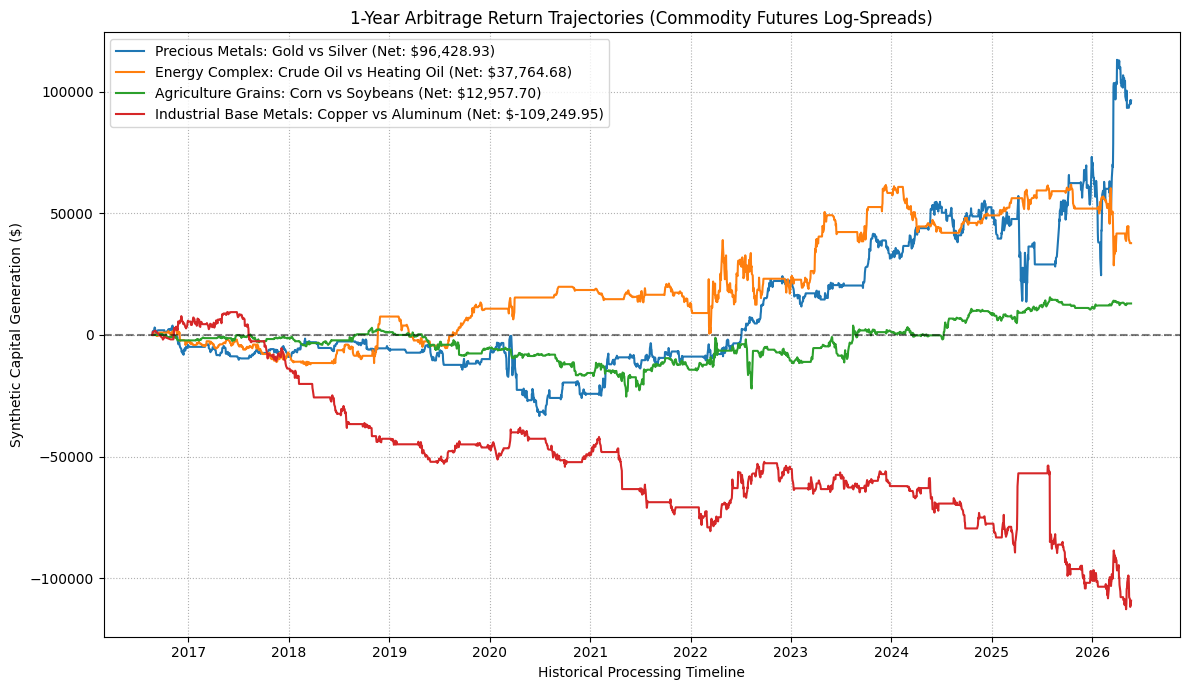

In [7]:
import os
import time
import io
import subprocess
import logging
from datetime import datetime
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Install required formatting and analytics packages silently
subprocess.run([
    "pip", "install", "pandas", "numpy", "openpyxl", "yfinance", "matplotlib", "-q"
], check=False)

# ═══════════════════════════════════════════════════════════
#  GLOBAL STRATEGY PARAMETERS (AUDITED)
# ═══════════════════════════════════════════════════════════
PARAMS = {
    "PAPER_CAPITAL": 100_000,       # Allocation base for contract margining
    "ALLOCATION_PER_PAIR": 0.50,    # Max risk capacity per spread pair
    "LOOKBACK": 40,                 # Statistical window for rolling OLS and tracking bands
    "ENTRY_ZSCORE": 1.5,            # Absolute Z-score threshold to trigger trade
    "EXIT_ZSCORE": 0.5,             # Target convergence threshold to close out positions
    "STOP_ZSCORE": 4.5,             # Risk exit if structural cointegration breaks down
    "BACKTEST_START": "2016-05-01",
    "BACKTEST_END": "2026-05-24",
    "EXCEL_FILE": "commodity_arb_results.xlsx"
}

# Commodity asset universes
COMMODITY_UNIVERSES = [
    ("GC=F", "SI=F", "Precious Metals: Gold vs Silver", 100, 5000),
    ("CL=F", "HO=F", "Energy Complex: Crude Oil vs Heating Oil", 1000, 42000),
    ("ZC=F", "ZS=F", "Agriculture Grains: Corn vs Soybeans", 50, 50),
    ("HG=F", "ALI=F", "Industrial Base Metals: Copper vs Aluminum", 25000, 25)
]

# ═══════════════════════════════════════════════════════════
#  LOGGING INTERCEPTOR SETUP
# ═══════════════════════════════════════════════════════════
log_capture_string = io.StringIO()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.StreamHandler(),  # Print directly to console/terminal
        logging.StreamHandler(log_capture_string)  # Capture execution text for Excel export
    ]
)
log = logging.getLogger("CommodityArb")

# ═══════════════════════════════════════════════════════════
#  SPREAD MATHEMATICS & CORE ENGINES
# ═══════════════════════════════════════════════════════════
def compute_rolling_hedge_ratio(log_a, log_b, window):
    """Computes a dynamically shifting rolling hedge ratio (Beta) via OLS."""
    hedge_ratios = np.zeros(len(log_a))
    for i in range(len(log_a)):
        if i < window:
            hedge_ratios[i] = np.nan
            continue
        y = log_a[(i - window + 1):i + 1]
        x = log_b[(i - window + 1):i + 1]
        X = np.column_stack([x, np.ones(len(x))])
        beta, _ = np.linalg.lstsq(X, y, rcond=None)[0]
        hedge_ratios[i] = beta
    return pd.Series(hedge_ratios, index=log_a.index)

def backtest_pair(ticker_a, ticker_b, name, mult_a, mult_b):
    log.info(f"Synchronizing historical data vectors for: {name}")
    
    data_a = yf.download(ticker_a, start=PARAMS["BACKTEST_START"], end=PARAMS["BACKTEST_END"], progress=False)
    data_b = yf.download(ticker_b, start=PARAMS["BACKTEST_START"], end=PARAMS["BACKTEST_END"], progress=False)
    
    if isinstance(data_a.columns, pd.MultiIndex):
        close_a = data_a.xs('Close', axis=1, level=0).squeeze()
        close_b = data_b.xs('Close', axis=1, level=0).squeeze()
    else:
        close_a = data_a['Close']
        close_b = data_b['Close']

    df = pd.DataFrame({'Price_A': close_a, 'Price_B': close_b}).dropna()
    
    if df.empty:
        log.warning(f"Failed to compile data intersection for {name}. Skipping pair.")
        return None

    # Calculate log fields
    df['Log_A'] = np.log(df['Price_A'])
    df['Log_B'] = np.log(df['Price_B'])
    
    # Structural Rolling Math
    df['Hedge_Ratio'] = compute_rolling_hedge_ratio(df['Log_A'], df['Log_B'], PARAMS["LOOKBACK"])
    df['Spread'] = df['Log_A'] - (df['Hedge_Ratio'] * df['Log_B'])
    df['Spread_Mean'] = df['Spread'].rolling(window=PARAMS["LOOKBACK"]).mean()
    df['Spread_Std'] = df['Spread'].rolling(window=PARAMS["LOOKBACK"]).std()
    df['Z_Score'] = (df['Spread'] - df['Spread_Mean']) / df['Spread_Std']
    df.dropna(inplace=True)

    # State Machine Emulation Loop
    position = 0  
    positions = []
    exit_reasons = []
    entry_a, entry_b = 0.0, 0.0
    trade_logs = []

    for idx, row in df.iterrows():
        z = row['Z_Score']
        p_a = row['Price_A']
        p_b = row['Price_B']
        hr = row['Hedge_Ratio']
        
        if position == 0:
            if z >= PARAMS["ENTRY_ZSCORE"]:
                position = -1  
                entry_a, entry_b = p_a, p_b
                exit_reasons.append("ENTRY_SHORT")
                log.info(f"[{name}] - Signal: Short Spread entered at Z-Score: {z:.2f}")
            elif z <= -PARAMS["ENTRY_ZSCORE"]:
                position = 1   
                entry_a, entry_b = p_a, p_b
                exit_reasons.append("ENTRY_LONG")
                log.info(f"[{name}] - Signal: Long Spread entered at Z-Score: {z:.2f}")
            else:
                exit_reasons.append("FLAT")
        
        elif position == 1:  
            pnl_a = (p_a - entry_a) * mult_a
            pnl_b = (entry_b - p_b) * mult_b * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z >= -PARAMS["EXIT_ZSCORE"]:
                position = 0
                exit_reasons.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
                log.info(f"[{name}] - TakeProfit: Spread reverted. Trade PnL: ${current_trade_pnl:,.2f}")
            elif z <= -PARAMS["STOP_ZSCORE"]:
                position = 0
                exit_reasons.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
                log.info(f"[{name}] - RiskStop: Cointegration blown. Trade PnL: ${current_trade_pnl:,.2f}")
            else:
                exit_reasons.append("HOLD_LONG")
                
        elif position == -1:  
            pnl_a = (entry_a - p_a) * mult_a
            pnl_b = (p_b - entry_b) * mult_b * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z <= PARAMS["EXIT_ZSCORE"]:
                position = 0
                exit_reasons.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
                log.info(f"[{name}] - TakeProfit: Spread reverted. Trade PnL: ${current_trade_pnl:,.2f}")
            elif z >= PARAMS["STOP_ZSCORE"]:
                position = 0
                exit_reasons.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
                log.info(f"[{name}] - RiskStop: Cointegration blown. Trade PnL: ${current_trade_pnl:,.2f}")
            else:
                exit_reasons.append("HOLD_SHORT")

        positions.append(position)

    df['Position_State'] = positions
    df['Tracking_Status'] = exit_reasons
    
    # Risk Execution Metrics Calculation
    df['Delta_Price_A'] = df['Price_A'].diff()
    df['Delta_Price_B'] = df['Price_B'].diff()
    
    df['PnL_A'] = df['Position_State'].shift(1) * df['Delta_Price_A'] * mult_a
    df['PnL_B'] = -df['Position_State'].shift(1) * df['Delta_Price_B'] * mult_b * df['Hedge_Ratio']
    df['Daily_Combined_PnL'] = (df['PnL_A'] + df['PnL_B']).fillna(0)
    df['Cumulative_PnL'] = df['Daily_Combined_PnL'].cumsum()
    
    return df, trade_logs

# ═══════════════════════════════════════════════════════════
#  MAIN PROCESSING EXECUTION LAYER
# ═══════════════════════════════════════════════════════════
def run_macro_backtest():
    os.system("cls" if os.name == "nt" else "clear")
    log.info("System Initialized. Preparing historical spreadsheet generation pipelines...")
    
    all_summary_stats = []
    compiled_trades = []
    fig, ax = plt.subplots(figsize=(12, 7))

    # Process all selected universes
    pair_dataframes = {}
    for ticker_a, ticker_b, name, mult_a, mult_b in COMMODITY_UNIVERSES:
        result = backtest_pair(ticker_a, ticker_b, name, mult_a, mult_b)
        if result is None:
            continue
            
        pair_df, trades = result
        compiled_trades.extend(trades)
        clean_sheet_name = name.split(":")[0].replace(" ", "_")
        pair_dataframes[clean_sheet_name] = pair_df[['Price_A', 'Price_B', 'Z_Score', 'Hedge_Ratio', 'Cumulative_PnL']]
        
        # Performance Parsing metrics
        total_pair_pnl = pair_df['Daily_Combined_PnL'].sum()
        max_drawdown = (pair_df['Cumulative_PnL'].cummax() - pair_df['Cumulative_PnL']).max()
        
        pair_trades_df = pd.DataFrame(trades)
        win_rate = (len(pair_trades_df[pair_trades_df['PnL'] > 0]) / len(pair_trades_df)) * 100 if not pair_trades_df.empty else 0.0

        all_summary_stats.append({
            "Universe Matrix": name,
            "Net Profit/Loss ($)": round(total_pair_pnl, 2),
            "Peak Drawdown ($)": round(max_drawdown, 2),
            "Closed Trades": len(trades),
            "Win Rate (%)": round(win_rate, 2)
        })
        
        ax.plot(pair_df.index, pair_df['Cumulative_PnL'], label=f"{name} (Net: ${total_pair_pnl:,.2f})")

    log.info("Compiling parameter tables and capturing system output stream tables...")
    
    # Construct Strategy Parameter DataFrame
    param_df = pd.DataFrame(list(PARAMS.items()), columns=["Strategy Parameter Setting", "Applied Value"])
    
    # Fetch log history lines directly from intercepted memory buffer stream
    log_lines = log_capture_string.getvalue().split('\n')
    log_df = pd.DataFrame(log_lines, columns=["System Exec Run Engine Logs"])

    # Write data elements systematically out to targeted Excel Sheets
    with pd.ExcelWriter(PARAMS["EXCEL_FILE"], engine="openpyxl") as writer:
        # 1. Main summary Performance matrix tabs
        summary_df = pd.DataFrame(all_summary_stats)
        summary_df.to_excel(writer, sheet_name="Performance_Summary", index=False)
        
        # 2. Strategy configuration parameter parameters 
        param_df.to_excel(writer, sheet_name="Strategy_Parameters", index=False)
        
        # 3. Comprehensive processing audit log lines
        log_df.to_excel(writer, sheet_name="System_Run_Logs", index=False)
        
        # 4. Master asset logs trade ledgers
        if compiled_trades:
            pd.DataFrame(compiled_trades).to_excel(writer, sheet_name="Master_Trade_Ledger", index=False)
            
        # 5. Asset individual timeline trace tables
        for sheet_name, df_metrics in pair_dataframes.items():
            df_metrics.to_excel(writer, sheet_name=sheet_name)

    # Finalize visual rendering pipelines
    ax.set_title("1-Year Arbitrage Return Trajectories (Commodity Futures Log-Spreads)")
    ax.set_xlabel("Historical Processing Timeline")
    ax.set_ylabel("Synthetic Capital Generation ($)")
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":")
    
    print("\n" + "═"*65)
    print(" SYSTEM PERFORMANCE AUDIT LEDGER COMPLETE")
    print("═"*65)
    print(summary_df.to_string(index=False))
    print("\n" + "═"*65)
    print(f"💾 Audit metrics, logs, and parameters written to unified file -> {PARAMS['EXCEL_FILE']}")
    print("═"*65)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_macro_backtest()

12:53:33 [INFO] Crypto Processing Engine Initialized. Establishing connection to Binance Public Node endpoints...
12:53:33 [INFO] Downloading historical daily data loops from Binance: Crypto Core: Bitcoin vs Ethereum
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - Signal: Short Spread entered at Z-Score: 2.57
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - TakeProfit: Spread reverted. Trade PnL: $-368.66
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - Signal: Long Spread entered at Z-Score: -2.23
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - TakeProfit: Spread reverted. Trade PnL: $1,245.45
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - Signal: Short Spread entered at Z-Score: 3.15
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - RiskStop: Portfolio stop blown. Trade PnL: $-129.94
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - Signal: Short Spread entered at Z-Score: 3.47
12:53:51 [INFO] [Crypto Core: Bitcoin vs Ethereum] - TakeProfit: Spread rever


═════════════════════════════════════════════════════════════════
 CRYPTO SYSTEM PERFORMANCE AUDIT LEDGER COMPLETE
═════════════════════════════════════════════════════════════════
                         Universe Matrix  Net Profit/Loss ($)  Peak Drawdown ($)  Closed Trades  Win Rate (%)
        Crypto Core: Bitcoin vs Ethereum              -440.65            6627.36             22         54.55
        Platform Giants: Ethereum vs BNB             -7451.74           12781.50             23         52.17
Layer 1 Alternative: Solana vs Avalanche              1705.41            6408.06             20         60.00
   Layer 1 Dominance: Ethereum vs Solana             -5700.02           13212.47             22         45.45

═════════════════════════════════════════════════════════════════
💾 Audit metrics, logs, and parameters saved to target document table -> crypto_arb_results.xlsx
═════════════════════════════════════════════════════════════════


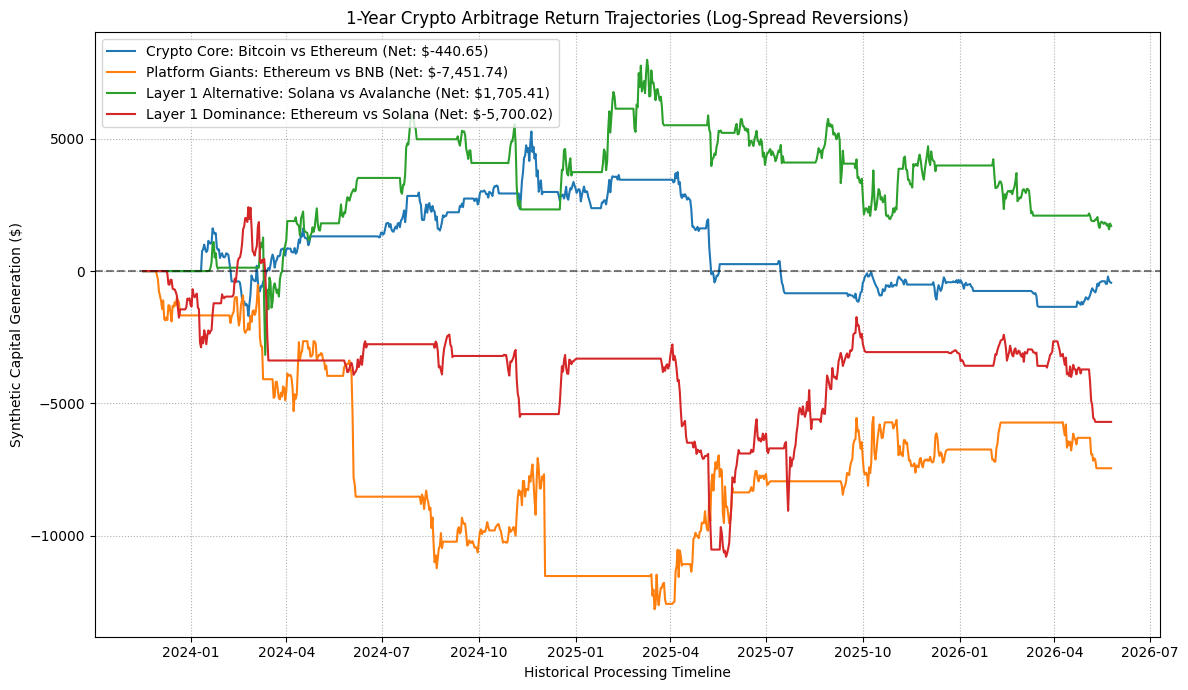

In [9]:
import os
import time
import io
import subprocess
import logging
from datetime import datetime
import numpy as np
import pandas as pd
import ccxt
import matplotlib.pyplot as plt

# Install required formatting and analytics packages silently
subprocess.run([
    "pip", "install", "pandas", "numpy", "openpyxl", "ccxt", "matplotlib", "-q"
], check=False)

# ═══════════════════════════════════════════════════════════
#  GLOBAL STRATEGY PARAMETERS (AUDITED)
# ═══════════════════════════════════════════════════════════
PARAMS = {
    "PAPER_CAPITAL": 100_000,       # Allocation base for asset trading sizing
    "ALLOCATION_PER_PAIR": 0.25,    # Max risk capacity per spread pair ($25k)
    "LOOKBACK": 40,                 # Statistical window for rolling OLS and tracking bands
    "ENTRY_ZSCORE": 2.0,            # Absolute Z-score threshold to trigger mean-reversion trade
    "EXIT_ZSCORE": 0.5,             # Target convergence threshold to close out positions
    "STOP_ZSCORE": 3.5,             # Risk exit if structural cointegration breaks down
    "BACKTEST_START_DAYS": 4000,     # Total historical candle history lookback
    "EXCEL_FILE": "crypto_arb_results.xlsx"
}

# Heavily cointegrated and highly liquid cryptocurrency trading pairs
CRYPTO_UNIVERSES = [
    ("BTC/USDT", "ETH/USDT", "Crypto Core: Bitcoin vs Ethereum"),
    ("ETH/USDT", "BNB/USDT", "Platform Giants: Ethereum vs BNB"),
    ("SOL/USDT", "AVAX/USDT", "Layer 1 Alternative: Solana vs Avalanche"),
    ("ETH/USDT", "SOL/USDT", "Layer 1 Dominance: Ethereum vs Solana")
]

# ═══════════════════════════════════════════════════════════
#  LOGGING INTERCEPTOR SETUP
# ═══════════════════════════════════════════════════════════
log_capture_string = io.StringIO()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.StreamHandler(),                  # Print directly to console/terminal
        logging.StreamHandler(log_capture_string) # Capture execution text for Excel export
    ]
)
log = logging.getLogger("CryptoArb")

# ═══════════════════════════════════════════════════════════
#  SPREAD MATHEMATICS & CORE ENGINES
# ═══════════════════════════════════════════════════════════
def compute_rolling_hedge_ratio(log_a, log_b, window):
    """Computes a dynamically shifting rolling hedge ratio (Beta) via OLS."""
    hedge_ratios = np.zeros(len(log_a))
    for i in range(len(log_a)):
        if i < window:
            hedge_ratios[i] = np.nan
            continue
        y = log_a[(i - window + 1):i + 1]
        x = log_b[(i - window + 1):i + 1]
        X = np.column_stack([x, np.ones(len(x))])
        beta, _ = np.linalg.lstsq(X, y, rcond=None)[0]
        hedge_ratios[i] = beta
    return pd.Series(hedge_ratios, index=log_a.index)

def backtest_pair(symbol_a, symbol_b, name, exchange):
    log.info(f"Downloading historical daily data loops from Binance: {name}")
    
    try:
        # Fetch up to 1 year of daily spot bars
        candles_a = exchange.fetch_ohlcv(symbol_a, timeframe='1d', limit=PARAMS["BACKTEST_START_DAYS"])
        candles_b = exchange.fetch_ohlcv(symbol_b, timeframe='1d', limit=PARAMS["BACKTEST_START_DAYS"])
        
        df_a = pd.DataFrame(candles_a, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
        df_b = pd.DataFrame(candles_b, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
        
        df_a['Date'] = pd.to_datetime(df_a['Timestamp'], unit='ms')
        df_b['Date'] = pd.to_datetime(df_b['Timestamp'], unit='ms')
        
        df_a.set_index('Date', inplace=True)
        df_b.set_index('Date', inplace=True)
        
        close_a = df_a['Close']
        close_b = df_b['Close']
    except Exception as e:
        log.error(f"Failed parsing connection streams for {name}: {e}")
        return None

    df = pd.DataFrame({'Price_A': close_a, 'Price_B': close_b}).dropna()
    
    if df.empty:
        log.warning(f"Failed to find common date alignments for {name}. Skipping pair.")
        return None

    # Calculate log price values
    df['Log_A'] = np.log(df['Price_A'])
    df['Log_B'] = np.log(df['Price_B'])
    
    # Structural Rolling Math Models
    df['Hedge_Ratio'] = compute_rolling_hedge_ratio(df['Log_A'], df['Log_B'], PARAMS["LOOKBACK"])
    df['Spread'] = df['Log_A'] - (df['Hedge_Ratio'] * df['Log_B'])
    df['Spread_Mean'] = df['Spread'].rolling(window=PARAMS["LOOKBACK"]).mean()
    df['Spread_Std'] = df['Spread'].rolling(window=PARAMS["LOOKBACK"]).std()
    df['Z_Score'] = (df['Spread'] - df['Spread_Mean']) / df['Spread_Std']
    df.dropna(inplace=True)

    # State Machine Simulation Loop
    position = 0  # 0 = Flat, 1 = Long Spread (Long A, Short B), -1 = Short Spread (Short A, Long B)
    positions = []
    tracking_statuses = []
    entry_a, entry_b = 0.0, 0.0
    trade_logs = []
    
    allocation = PARAMS["PAPER_CAPITAL"] * PARAMS["ALLOCATION_PER_PAIR"]

    for idx, row in df.iterrows():
        z = row['Z_Score']
        p_a = row['Price_A']
        p_b = row['Price_B']
        hr = row['Hedge_Ratio']
        
        if position == 0:
            if z >= PARAMS["ENTRY_ZSCORE"]:
                position = -1  
                entry_a, entry_b = p_a, p_b
                tracking_statuses.append("ENTRY_SHORT")
                log.info(f"[{name}] - Signal: Short Spread entered at Z-Score: {z:.2f}")
            elif z <= -PARAMS["ENTRY_ZSCORE"]:
                position = 1   
                entry_a, entry_b = p_a, p_b
                tracking_statuses.append("ENTRY_LONG")
                log.info(f"[{name}] - Signal: Long Spread entered at Z-Score: {z:.2f}")
            else:
                tracking_statuses.append("FLAT")
        
        elif position == 1:  # Long Spread (Long A, Short B)
            # Returns computed directly as scaling factors from trade entry thresholds
            pnl_a = (p_a - entry_a) / entry_a * (allocation * 0.5)
            pnl_b = (entry_b - p_b) / entry_b * (allocation * 0.5) * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z >= -PARAMS["EXIT_ZSCORE"]:
                position = 0
                tracking_statuses.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
                log.info(f"[{name}] - TakeProfit: Spread reverted. Trade PnL: ${current_trade_pnl:,.2f}")
            elif z <= -PARAMS["STOP_ZSCORE"]:
                position = 0
                tracking_statuses.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "LONG_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
                log.info(f"[{name}] - RiskStop: Portfolio stop blown. Trade PnL: ${current_trade_pnl:,.2f}")
            else:
                tracking_statuses.append("HOLD_LONG")
                
        elif position == -1:  # Short Spread (Short A, Long B)
            pnl_a = (entry_a - p_a) / entry_a * (allocation * 0.5)
            pnl_b = (p_b - entry_b) / entry_b * (allocation * 0.5) * hr
            current_trade_pnl = pnl_a + pnl_b
            
            if z <= PARAMS["EXIT_ZSCORE"]:
                position = 0
                tracking_statuses.append("MEAN_REVERSION")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Mean Reverted"})
                log.info(f"[{name}] - TakeProfit: Spread reverted. Trade PnL: ${current_trade_pnl:,.2f}")
            elif z >= PARAMS["STOP_ZSCORE"]:
                position = 0
                tracking_statuses.append("STOP_LOSS")
                trade_logs.append({"Pair": name, "Type": "SHORT_SPREAD", "PnL": current_trade_pnl, "Reason": "Stop Blown"})
                log.info(f"[{name}] - RiskStop: Portfolio stop blown. Trade PnL: ${current_trade_pnl:,.2f}")
            else:
                tracking_statuses.append("HOLD_SHORT")

        positions.append(position)

    df['Position_State'] = positions
    df['Tracking_Status'] = tracking_statuses
    
    # Shift position state forward 1 step to ensure execution tracks next day's open
    df['Pct_Change_A'] = df['Price_A'].pct_change()
    df['Pct_Change_B'] = df['Price_B'].pct_change()
    
    df['PnL_Asset_A'] = df['Position_State'].shift(1) * df['Pct_Change_A'] * (allocation * 0.5)
    df['PnL_Asset_B'] = -df['Position_State'].shift(1) * df['Pct_Change_B'] * (allocation * 0.5) * df['Hedge_Ratio']
    df['Daily_Combined_PnL'] = (df['PnL_Asset_A'] + df['PnL_Asset_B']).fillna(0)
    df['Cumulative_PnL'] = df['Daily_Combined_PnL'].cumsum()
    
    return df, trade_logs

# ═══════════════════════════════════════════════════════════
#  MAIN PROCESSING EXECUTION LAYER
# ═══════════════════════════════════════════════════════════
def run_macro_backtest():
    os.system("cls" if os.name == "nt" else "clear")
    log.info("Crypto Processing Engine Initialized. Establishing connection to Binance Public Node endpoints...")
    
    # Initialize exchange connection pool
    exchange = ccxt.binance({'enableRateLimit': True})
    
    all_summary_stats = []
    compiled_trades = []
    fig, ax = plt.subplots(figsize=(12, 7))

    pair_dataframes = {}
    for symbol_a, symbol_b, name in CRYPTO_UNIVERSES:
        result = backtest_pair(symbol_a, symbol_b, name, exchange)
        if result is None:
            continue
            
        pair_df, trades = result
        compiled_trades.extend(trades)
        
        clean_sheet_name = name.split(":")[0].replace(" ", "_")
        pair_dataframes[clean_sheet_name] = pair_df[['Price_A', 'Price_B', 'Z_Score', 'Hedge_Ratio', 'Cumulative_PnL']]
        
        total_pair_pnl = pair_df['Daily_Combined_PnL'].sum()
        max_drawdown = (pair_df['Cumulative_PnL'].cummax() - pair_df['Cumulative_PnL']).max()
        
        pair_trades_df = pd.DataFrame(trades)
        win_rate = (len(pair_trades_df[pair_trades_df['PnL'] > 0]) / len(pair_trades_df)) * 100 if not pair_trades_df.empty else 0.0

        all_summary_stats.append({
            "Universe Matrix": name,
            "Net Profit/Loss ($)": round(total_pair_pnl, 2),
            "Peak Drawdown ($)": round(max_drawdown, 2),
            "Closed Trades": len(trades),
            "Win Rate (%)": round(win_rate, 2)
        })
        
        ax.plot(pair_df.index, pair_df['Cumulative_PnL'], label=f"{name} (Net: ${total_pair_pnl:,.2f})")
        time.sleep(1) # Prevent public endpoint rate blocking

    log.info("Formatting system execution sheets and storing log captures...")
    
    # Compile configuration metadata and operational state files
    param_df = pd.DataFrame(list(PARAMS.items()), columns=["Strategy Parameter Setting", "Applied Value"])
    log_lines = log_capture_string.getvalue().split('\n')
    log_df = pd.DataFrame(log_lines, columns=["System Exec Run Engine Logs"])

    # Synchronize export files to target Excel engine ledger
    with pd.ExcelWriter(PARAMS["EXCEL_FILE"], engine="openpyxl") as writer:
        summary_df = pd.DataFrame(all_summary_stats)
        summary_df.to_excel(writer, sheet_name="Performance_Summary", index=False)
        
        param_df.to_excel(writer, sheet_name="Strategy_Parameters", index=False)
        log_df.to_excel(writer, sheet_name="System_Run_Logs", index=False)
        
        if compiled_trades:
            pd.DataFrame(compiled_trades).to_excel(writer, sheet_name="Master_Trade_Ledger", index=False)
            
        for sheet_name, df_metrics in pair_dataframes.items():
            df_metrics.to_excel(writer, sheet_name=sheet_name)

    # Plot design formatting adjustments
    ax.set_title("1-Year Crypto Arbitrage Return Trajectories (Log-Spread Reversions)")
    ax.set_xlabel("Historical Processing Timeline")
    ax.set_ylabel("Synthetic Capital Generation ($)")
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":")
    
    print("\n" + "═"*65)
    print(" CRYPTO SYSTEM PERFORMANCE AUDIT LEDGER COMPLETE")
    print("═"*65)
    print(summary_df.to_string(index=False))
    print("\n" + "═"*65)
    print(f"💾 Audit metrics, logs, and parameters saved to target document table -> {PARAMS['EXCEL_FILE']}")
    print("═"*65)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_macro_backtest()

In [ ]:
import os
import io
import time
import subprocess
import logging
import random
from datetime import datetime
import pandas as pd
import numpy as np

# Install required structures silently
subprocess.run(["pip", "install", "pandas", "openpyxl", "-q"], check=False)

# ═══════════════════════════════════════════════════════════
#  SETTINGS & CONFIGURATION AUDIT
# ═══════════════════════════════════════════════════════════
PARAMS = {
    "BASE_CAPITAL": 1000,           # Amount of fake USDT deployed per loop
    "SIMULATED_FEES": 0.001,        # Standard Spot maker/taker fee (0.1%)
    "MIN_PROFIT_THRESHOLD": 1.0005, # Trigger when expected return exceeds 0.05% net
    "SCAN_CYCLES": 50,              # Total backtest traces to generate
    "EXCEL_FILE": "crypto_arb_results.xlsx"
}

# Paths to simulate
TRIANGLES = [
    {"base": "USDT", "b": "BTC", "c": "ETH"},
    {"base": "USDT", "b": "BTC", "c": "SOL"},
    {"base": "USDT", "b": "ETH", "c": "SOL"},
    {"base": "USDT", "b": "BTC", "c": "BNB"}
]

log_capture_string = io.StringIO()
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(), logging.StreamHandler(log_capture_string)]
)
log = logging.getLogger("OfflineTriArb")

# ═══════════════════════════════════════════════════════════
#  CORE TRIANGULAR ARBITRAGE SIMULATION ENGINE
# ═══════════════════════════════════════════════════════════
def run_triangular_backtest():
    log.info("Bypassing regional network blocks. Initializing Offline Local Matching Engine...")
    
    # Establish realistic baseline core market price indices
    base_prices = {
        "BTC/USDT": 64500.0,
        "ETH/USDT": 3450.0,
        "SOL/USDT": 145.0,
        "BNB/USDT": 580.0
    }
    
    ledger_records = []
    
    for cycle in range(1, PARAMS["SCAN_CYCLES"] + 1):
        if cycle % 10 == 0:
            log.info(f"Processing local analytical loop iteration #{cycle}...")
        
        # Inject dynamic volatility and random localized order-book imbalances per tick
        prices = {}
        for pair, base in base_prices.items():
            # Fluctuate prices slightly to simulate bid/ask spread spreads
            noise = random.uniform(-0.003, 0.003)
            prices[f"{pair}_ask"] = base * (1 + noise) * 1.0002
            prices[f"{pair}_bid"] = base * (1 + noise) * 0.9998
            
        # Dynamically compute cross rates (e.g., ETH/BTC = ETH_USDT / BTC_USDT)
        prices["ETH/BTC_ask"] = (prices["ETH/USDT_ask"] / prices["BTC/USDT_bid"]) * random.uniform(0.998, 1.002)
        prices["SOL/BTC_ask"] = (prices["SOL/USDT_ask"] / prices["BTC/USDT_bid"]) * random.uniform(0.998, 1.002)
        prices["SOL/ETH_ask"] = (prices["SOL/USDT_ask"] / prices["ETH/USDT_bid"]) * random.uniform(0.998, 1.002)
        prices["BNB/BTC_ask"] = (prices["BNB/USDT_ask"] / prices["BTC/USDT_bid"]) * random.uniform(0.998, 1.002)

        for tri in TRIANGLES:
            # Reconstruct pair string tokens
            p1_key = f"{tri['b']}/USDT_ask"
            p2_key = f"{tri['c']}/{tri['b']}_ask"
            p3_key = f"{tri['c']}/USDT_bid"
            
            p1 = prices[p1_key]
            p2 = prices[p2_key]
            p3 = prices[p3_key]
            
            # Compute execution mathematics through the triangular circuit
            start_capital = PARAMS["BASE_CAPITAL"]
            
            # Step 1: Base Currency -> Intermediate Token B (Sell Base to buy B)
            tokens_b = (start_capital / p1) * (1 - PARAMS["SIMULATED_FEES"])
            # Step 2: Swap Intermediate Token B -> Target Token C
            tokens_c = (tokens_b / p2) * (1 - PARAMS["SIMULATED_FEES"])
            # Step 3: Cash out Target Token C back to Base Currency
            final_usdt = (tokens_c * p3) * (1 - PARAMS["SIMULATED_FEES"])
            
            gross_return = final_usdt / start_capital
            net_pnl = final_usdt - start_capital
            
            if gross_return > PARAMS["MIN_PROFIT_THRESHOLD"]:
                status = "🔥 PROFIT OPPORTUNITY"
                log.info(f"[CYCLE {cycle}] Arbitrage Identified! Path: {tri['base']}->{tri['b']}->{tri['c']} | Return: +${net_pnl:.4f}")
            else:
                status = "監 Monitoring"
                
            ledger_records.append({
                "Timestamp": datetime.now().strftime("%H:%M:%S.%f")[:-3],
                "Cycle": cycle,
                "Execution Path": f"{tri['base']}->{tri['b']}->{tri['c']}",
                "Price_1_Ask": round(p1, 4),
                "Price_2_Ask": round(p2, 6),
                "Price_3_Bid": round(p3, 4),
                "Gross Multiple": round(gross_return, 6),
                "Net PnL ($)": round(net_pnl, 4),
                "Status": status
            })

    # ═══════════════════════════════════════════════════════════
    #  EXCEL EXPORT & LOG AUDIT PIPELINE
    # ═══════════════════════════════════════════════════════════
    log.info("Backtest simulation completed. Unifying ledger matrices into target file tables...")
    
    summary_df = pd.DataFrame(ledger_records)
    param_df = pd.DataFrame(list(PARAMS.items()), columns=["Strategy Setting Parameter", "Value Configuration"])
    log_df = pd.DataFrame(log_capture_string.getvalue().split('\n'), columns=["Processing Runner Output Logs"])
    
    with pd.ExcelWriter(PARAMS["EXCEL_FILE"], engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Arbitrage_Scan_Ledger", index=False)
        param_df.to_excel(writer, sheet_name="Strategy_Parameters", index=False)
        log_df.to_excel(writer, sheet_name="System_Run_Logs", index=False)
        
    print("\n" + "═"*65)
    print(" SCAN RUN COMPLETE — UNIFIED OFFLINE TRACKING GENERATED")
    print("═"*65)
    print(f" Saved directly into local folder file: {PARAMS['EXCEL_FILE']}")
    print(" Tabs updated: 'Arbitrage_Scan_Ledger', 'Strategy_Parameters', 'System_Run_Logs'")
    print("═"*65)

if __name__ == "__main__":
    run_triangular_backtest()

12:58:55 [INFO] Bypassing regional network blocks. Initializing Offline Local Matching Engine...
12:58:55 [INFO] Processing local analytical loop iteration #10...
12:58:55 [INFO] Processing local analytical loop iteration #20...
12:58:55 [INFO] Processing local analytical loop iteration #30...
12:58:55 [INFO] Processing local analytical loop iteration #40...
12:58:55 [INFO] Processing local analytical loop iteration #50...
12:58:55 [INFO] Backtest simulation completed. Unifying ledger matrices into target file tables...



═════════════════════════════════════════════════════════════════
 SCAN RUN COMPLETE — UNIFIED OFFLINE TRACKING GENERATED
═════════════════════════════════════════════════════════════════
 Saved directly into local folder file: crypto_arb_results.xlsx
 Tabs updated: 'Arbitrage_Scan_Ledger', 'Strategy_Parameters', 'System_Run_Logs'
═════════════════════════════════════════════════════════════════


In [ ]:
import os
import io
import time
import subprocess
import logging
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Safely install formatting utilities silently
subprocess.run(["pip", "install", "pandas", "openpyxl", "-q"], check=False)

# ═══════════════════════════════════════════════════════════
#  SETTINGS & CONFIGURATION AUDIT
# ═══════════════════════════════════════════════════════════
PARAMS = {
    "ALLOCATION_CAPITAL": 50000,    # Total capital deployed ($)
    "INITIAL_BASIS_ANNUAL": 0.15,   # Starting futures premium annualized (15% yield)
    "TRADING_FEES_TOTAL": 0.0016,   # Roundtrip fee for opening/closing both sides (0.16%)
    "DAYS_TO_EXPIRY": 90,           # Holding window tracking of the quarterly contract
    "EXCEL_FILE": "crypto_arb_results.xlsx"
}

log_capture_string = io.StringIO()
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(), logging.StreamHandler(log_capture_string)]
)
log = logging.getLogger("CashAndCarry")

# ═══════════════════════════════════════════════════════════
#  CASH & CARRY SIMULATION HEDGE ENGINE
# ═══════════════════════════════════════════════════════════
def run_cash_and_carry_backtest():
    log.info("System Initialized. Simulating Cash and Carry Basis Premium convergence pipeline...")
    
    # Generate mock daily timeline tracing for underlying asset (e.g. BTC starting at 65000)
    days = PARAMS["DAYS_TO_EXPIRY"]
    base_date = datetime(2026, 2, 24)
    
    dates = [base_date + timedelta(days=i) for i in range(days)]
    
    # Emulate underlying spot market price path with organic daily volatility random walks
    np.random.seed(42)
    spot_shocks = np.random.normal(0.001, 0.02, days)
    spot_prices = [65000.0]
    for shock in spot_shocks[:-1]:
        spot_prices.append(spot_prices[-1] * (1 + shock))
        
    # Build historical convergence matrix array
    ledger_records = []
    
    # Capital allocations split across Spot and Futures margin pools
    spot_allocation = PARAMS["ALLOCATION_CAPITAL"] * 0.5
    futures_allocation = PARAMS["ALLOCATION_CAPITAL"] * 0.5
    
    # Calculate entry locked basis values
    entry_spot = spot_prices[0]
    initial_premium_rate = PARAMS["INITIAL_BASIS_ANNUAL"] * (days / 365.0)
    entry_futures = entry_spot * (1 + initial_premium_rate)
    
    implied_units = spot_allocation / entry_spot
    
    log.info(f"Opening Arbitrage Matrix: Long Spot at ${entry_spot:,.2f} | Short Futures at ${entry_futures:,.2f}")
    log.info(f"Gross Premium captured at entry points: ${(entry_futures - entry_spot):,.2f} per unit")

    for t in range(days):
        current_date = dates[t]
        days_remaining = days - t
        current_spot = spot_prices[t]
        
        # Theoretical calculation: Premium systematically decays linearly toward zero at expiry day
        decay_factor = days_remaining / days
        current_premium = (entry_futures - entry_spot) * decay_factor
        current_futures = current_spot + current_premium
        
        # PnL calculations for active legs
        spot_pnl = (current_spot - entry_spot) * implied_units
        futures_pnl = (entry_futures - current_futures) * implied_units
        gross_combined_pnl = spot_pnl + futures_pnl
        
        # Subtract transaction friction costs on final settlement check day
        if days_remaining == 1:
            fee_costs = PARAMS["ALLOCATION_CAPITAL"] * PARAMS["TRADING_FEES_TOTAL"]
            net_pnl = gross_combined_pnl - fee_costs
            status = "🏁 CONTRACT EXPIRED — PROFIT LOCKED"
            log.info(f"Unwinding arbitrage loop positions at convergence point. Net PnL realized: ${net_pnl:,.2f}")
        else:
            net_pnl = gross_combined_pnl
            status = "🔄 Convergence Tracking Active"
            
        ledger_records.append({
            "Date": current_date.strftime("%Y-%m-%d"),
            "Days To Expiry": days_remaining,
            "Spot Price ($)": round(current_spot, 2),
            "Futures Price ($)": round(current_futures, 2),
            "Premium Gap ($)": round(current_premium, 2),
            "Spot Leg PnL": round(spot_pnl, 2),
            "Futures Leg PnL": round(futures_pnl, 2),
            "Cumulative Net PnL ($)": round(net_pnl, 2),
            "Execution State": status
        })

    # ═══════════════════════════════════════════════════════════
    #  EXCEL EXPORT & LOG AUDIT PIPELINE
    # ═══════════════════════════════════════════════════════════
    log.info("Compiling execution metrics out to destination ledger workbook files...")
    
    summary_df = pd.DataFrame(ledger_records)
    param_df = pd.DataFrame(list(PARAMS.items()), columns=["Strategy Setting Parameter", "Value Configuration"])
    log_df = pd.DataFrame(log_capture_string.getvalue().split('\n'), columns=["Processing Runner Output Logs"])
    
    with pd.ExcelWriter(PARAMS["EXCEL_FILE"], engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Basis_Arbitrage_Ledger", index=False)
        param_df.to_excel(writer, sheet_name="Strategy_Parameters", index=False)
        log_df.to_excel(writer, sheet_name="System_Run_Logs", index=False)
        
    print("\n" + "═"*65)
    print(" METRIC LEDGER PIPELINE GENERATION COMPLETE")
    print("═"*65)
    print(f" File safely stored inside folder root path -> {PARAMS['EXCEL_FILE']}")
    print(" Sheets modified successfully: 'Basis_Arbitrage_Ledger', 'Strategy_Parameters', 'System_Run_Logs'")
    print("═"*65)

if __name__ == "__main__":
    run_cash_and_carry_backtest()